In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [21]:
data_analy= '/content/Consumer_Airfare_Report_Table.csv'
da = pd.read_csv(data_analy, encoding="unicode_escape")
da.head(10)


,Year,quarter,citymarketid,city,City_code,cur_passengers,cur_fare,cur_yield,distance,ly_passengers,ly_fare,ly_yield,ly_distance,tbl2pk
0,2021,4,34576,Rochester,NY,170560,162.92,25.13,648.2,42450.0,150.54,19.47,773.4,2021434576
1,2021,4,33495,New Orleans,LA,1571520,186.78,18.88,989.5,656740.0,150.32,14.74,1019.7,2021433495
2,2021,4,32337,Indianapolis,IN,1246520,206.51,19.79,1043.7,570540.0,164.68,15.26,1079.1,2021432337
3,2021,4,33214,San Antonio,TX,1219290,207.84,18.36,1131.7,530200.0,185.53,16.06,1155.0,2021433214
4,2021,4,32600,Little Rock,AR,126870,191.80,23.06,831.6,68150.0,166.98,18.49,902.9,2021432600
5,2021,4,30140,Albuquerque,NM,521750,203.89,22.58,903.2,167100.0,157.04,18.11,867.4,2021430140
6,2021,4,30325,Denver,CO,6208670,179.97,17.02,1057.6,2802410.0,140.07,13.06,1072.7,2021430325
7,2021,4,30529,Hartford,CT,759900,211.92,16.62,1275.1,227490.0,169.81,12.99,1307.4,2021430529
8,2021,4,31066,Columbus,OH,1025500,196.93,19.89,990.1,411130.0,161.60,15.04,1074.3,2021431066
9,2021,4,31871,Greenville/Spartanburg,SC,151150,196.13,29.28,669.7,53590.0,169.09,23.76,711.8,2021431871


In [22]:
#This method enable us to check the datatypes of the column which are in the given datasets
da.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8027 entries, 0 to 8026
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            8027 non-null   int64  
 1   quarter         8027 non-null   int64  
 2   citymarketid    8027 non-null   int64  
 3   city            8027 non-null   object 
 4   City_code       8027 non-null   object 
 5   cur_passengers  8027 non-null   int64  
 6   cur_fare        8027 non-null   float64
 7   cur_yield       8027 non-null   float64
 8   distance        8027 non-null   float64
 9   ly_passengers   8024 non-null   float64
 10  ly_fare         8024 non-null   float64
 11  ly_yield        8024 non-null   float64
 12  ly_distance     8024 non-null   float64
 13  tbl2pk          8027 non-null   int64  
dtypes: float64(7), int64(5), object(2)
memory usage: 878.1+ KB


In [23]:
#To ensure there is no null value in the datasets
#If there is a set of null value .Then we should know how many number of null values are present in the sets
pd.isnull(da).sum()

,0
Year,0
quarter,0
citymarketid,0
city,0
City_code,0
cur_passengers,0
cur_fare,0
cur_yield,0
distance,0
ly_passengers,3


In [24]:
#This code enable us to find the number of Rows and Column in the given data sets
da.shape

(8027, 14)

In [25]:
#As there certain number of null values are present in the given data we have to remove the null values from the datasets
da.dropna(inplace=True)

In [26]:
#After the removal of the null value in the data sets
#The total number of the null value in the data sets is displayed
pd.isnull(da).sum()

,0
Year,0
quarter,0
citymarketid,0
city,0
City_code,0
cur_passengers,0
cur_fare,0
cur_yield,0
distance,0
ly_passengers,0


In [27]:
#changing a datatypes of an column
# As the distance is measured in Nm. The decimal value can be negligible
# The intial datatype of the distance is float
# This method helps us to convert the float datasets into integer datasets
da['distance'] = da['distance'].astype('int')

In [28]:
#With the help of dtypes function we can find the datatype of particular column
da['distance'].dtypes

dtype('int64')

In [29]:
#Renaming a column
da.rename(columns= {'tbl2pk': 'trip_id'}, inplace=True)


In [47]:
#After the convertion of the datatype
da.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8024 entries, 0 to 8026
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            8024 non-null   int64  
 1   quarter         8024 non-null   int64  
 2   citymarketid    8024 non-null   int64  
 3   city            8024 non-null   object 
 4   City_code       8024 non-null   object 
 5   cur_passengers  8024 non-null   int64  
 6   cur_fare        8024 non-null   float64
 7   cur_yield       8024 non-null   float64
 8   distance        8024 non-null   int64  
 9   ly_passengers   8024 non-null   float64
 10  ly_fare         8024 non-null   float64
 11  ly_yield        8024 non-null   float64
 12  ly_distance     8024 non-null   float64
 13  trip_id         8024 non-null   int64  
dtypes: float64(6), int64(6), object(2)
memory usage: 940.3+ KB


In [31]:
#describe() method helps us to find the description of the data in dataframe(i.e count, mean, std, etc..,)
da['distance'].describe()

,distance
count,8024.000000
mean,963.170115
std,196.198533
min,334.000000
25%,853.000000
50%,971.000000
75%,1089.000000
max,1500.000000


In [32]:
#Displaying the colums of the dataframe
da.columns

Index(['Year', 'quarter', 'citymarketid', 'city', 'City_code',
       'cur_passengers', 'cur_fare', 'cur_yield', 'distance', 'ly_passengers',
       'ly_fare', 'ly_yield', 'ly_distance', 'trip_id'],
      dtype='object')

In [48]:
#value_count() method helps us to find the total number of repeatation in a particular dataset
city_count=da['city'].value_counts()
print(city_count)

city
Portland         167
New Orleans      112
Las Vegas        112
San Antonio      112
Hartford         112
                ... 
Santa Barbara      4
Everett            2
Trenton            2
Wichita            1
Tallahassee        1
Name: count, Length: 98, dtype: int64


In [52]:
city_name1 = 'New Orleans'
city_name2 = 'Miami'
city_name3 = 'Washington'
city_name4 = 'Los Angeles'

city_fares1 = da[da['city'] == city_name1]['cur_fare']
city_fares2 = da[da['city'] == city_name2]['cur_fare']
city_fares3 = da[da['city'] == city_name3]['cur_fare']
city_fares4 = da[da['city'] == city_name4]['cur_fare']

city_fares1_ly= da[da['city'] == city_name1]['ly_fare']
city_fares2_ly= da[da['city'] == city_name2]['ly_fare']
city_fares3_ly= da[da['city'] == city_name3]['ly_fare']
city_fares4_ly= da[da['city'] == city_name4]['ly_fare']

In [53]:
# Calculate the mean fare for the chosen city
mean_cur_fare1= city_fares1.mean()
mean_cur_fare2= city_fares2.mean()
mean_cur_fare3= city_fares3.mean()
mean_cur_fare4= city_fares4.mean()

#Caluculation of mean fare for the chosen city for last year
mean_ly_fare1= city_fares1_ly.mean()
mean_ly_fare2= city_fares2_ly.mean()
mean_ly_fare3= city_fares3_ly.mean()
mean_ly_fare4= city_fares4_ly.mean()

#storing the calculated values in the form of dictionary
cur_faretable = {'City': [city_name1,city_name2,city_name3,city_name4], 'Mean': [mean_cur_fare1,mean_cur_fare2,mean_cur_fare3,mean_cur_fare4],'Type':['Current Fare'] * 4}
ly_faretable = {'City': [city_name1,city_name2,city_name3,city_name4], 'Mean': [mean_ly_fare1,mean_ly_fare2,mean_ly_fare3,mean_ly_fare4],'Type':['Lastyear Fare'] * 4}
print('Current Fare Table:', cur_faretable)
print('Last Year Fare Table:', ly_faretable)

Current Fare Table: {'City': ['New Orleans', 'Miami', 'Washington', 'Los Angeles'], 'Mean': [np.float64(175.3899107142857), np.float64(174.0598214285714), np.float64(197.15401785714286), np.float64(195.28928571428568)], 'Type': ['Current Fare', 'Current Fare', 'Current Fare', 'Current Fare']}
Last Year Fare Table: {'City': ['New Orleans', 'Miami', 'Washington', 'Los Angeles'], 'Mean': [np.float64(172.84982142857143), np.float64(172.19696428571427), np.float64(195.37999999999997), np.float64(192.82919642857146)], 'Type': ['Lastyear Fare', 'Lastyear Fare', 'Lastyear Fare', 'Lastyear Fare']}


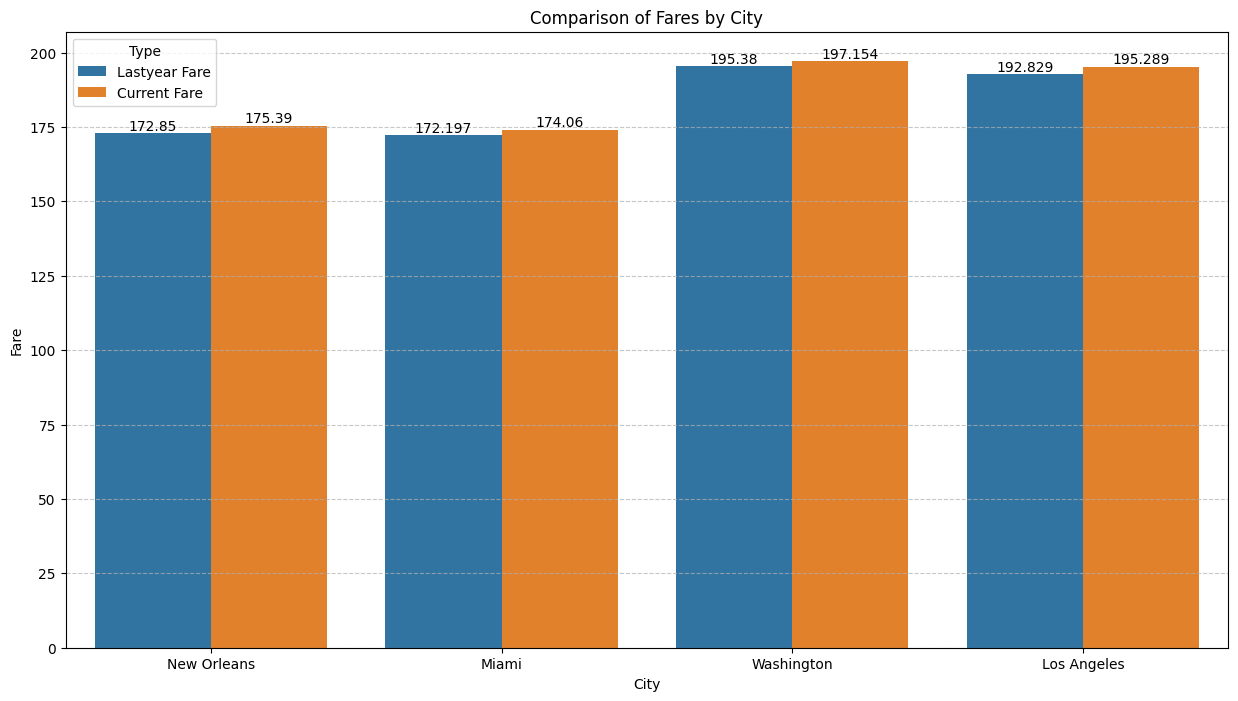

In [54]:
#converting the dictionaries to dataframes
df1=pd.DataFrame(ly_faretable)
df2=pd.DataFrame(cur_faretable)
df = pd.concat([df1, df2])

# Plotting the combined bar graph
plt.figure(figsize=(15, 8))

# Plot the  bar plot
dx=sns.barplot(x='City', y='Mean', hue='Type', data=df)

# Adding title and labels
plt.title('Comparison of Fares by City')
plt.xlabel('City')
plt.ylabel('Fare')
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bars in dx.containers:
    dx.bar_label(bars)

plt.show()

From the above graph it is clear that the mean of current airfare is slightly decreased from  the mean of last year airfare

In [55]:
cur_passenger1 = (da[da['city'] == city_name1]['cur_passengers']).mean()
cur_passenger2 = (da[da['city'] == city_name2]['cur_passengers']).mean()
cur_passenger3 = (da[da['city'] == city_name3]['cur_passengers']).mean()
cur_passenger4 = (da[da['city'] == city_name4]['cur_passengers']).mean()

ly_passenger1 = (da[da['city'] == city_name1]['ly_passengers']).mean()
ly_passenger2 = (da[da['city'] == city_name2]['ly_passengers']).mean()
ly_passenger3 = (da[da['city'] == city_name3]['ly_passengers']).mean()
ly_passenger4 = (da[da['city'] == city_name4]['ly_passengers']).mean()

cur_passenger = {'City':[city_name1,city_name2,city_name3,city_name4],'Mean':[cur_passenger1,cur_passenger2,cur_passenger3,cur_passenger4],'Type':['Current year Passanger']* 4}
ly_passenger = {'City':[city_name1,city_name2,city_name3,city_name4],'Mean':[ly_passenger1,ly_passenger2,ly_passenger3,ly_passenger4],'Type':['Last year Passanger']* 4}

print('Current Passenger Table:', cur_passenger)
print('Last Year Passenger Table:', ly_passenger)

Current Passenger Table: {'City': ['New Orleans', 'Miami', 'Washington', 'Los Angeles'], 'Mean': [np.float64(1494369.2857142857), np.float64(5455051.607142857), np.float64(7614775.357142857), np.float64(10695100.982142856)], 'Type': ['Current year Passanger', 'Current year Passanger', 'Current year Passanger', 'Current year Passanger']}
Last Year Passenger Table: {'City': ['New Orleans', 'Miami', 'Washington', 'Los Angeles'], 'Mean': [np.float64(1469478.0357142857), np.float64(5288269.553571428), np.float64(7489569.910714285), np.float64(10486608.92857143)], 'Type': ['Last year Passanger', 'Last year Passanger', 'Last year Passanger', 'Last year Passanger']}


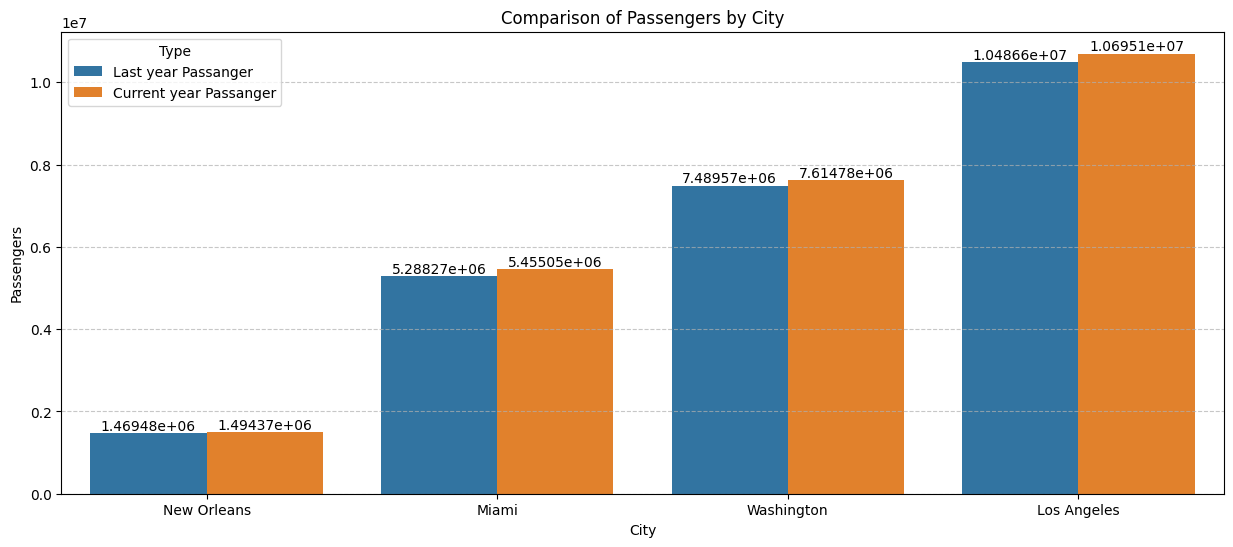

In [56]:
ds1=pd.DataFrame(ly_passenger)
ds2=pd.DataFrame(cur_passenger)
ds = pd.concat([ds1, ds2])

# Plotting the combined bar graph
plt.figure(figsize=(15, 6))

# Plot the  bar plot
ex=sns.barplot(x='City', y='Mean', hue='Type', data=ds)

# Adding title and labels
plt.title('Comparison of Passengers by City')
plt.xlabel('City')
plt.ylabel('Passengers')
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bars in ex.containers:
    ex.bar_label(bars)

plt.show()

From the above graph it clearly states that the number of passangers there is significant increase over a year


As the number of passengers traveled is significantly increased .Let's select 'New Orleans, LA' city from the above data and analayse the following parameters by Years(i.e 2007,2008,2009).The parameters are Passengers and Fares

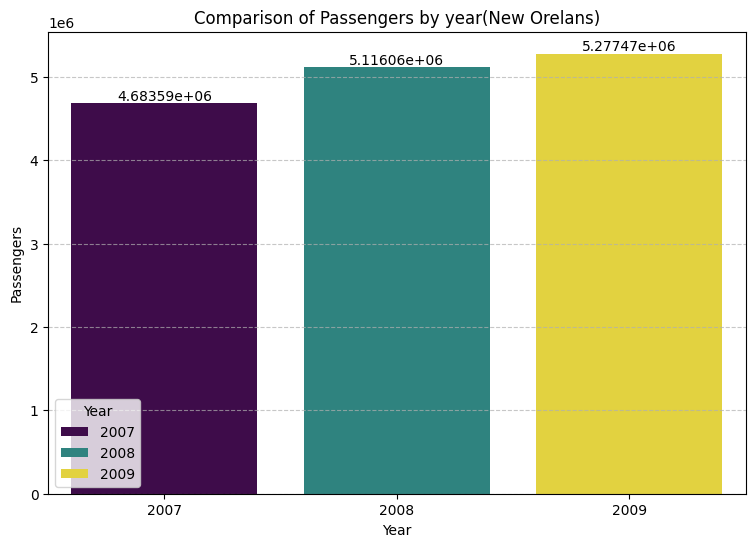

In [58]:
#Filtering out the sum of Passengers for the particular year
Passenger_cur1 = da[(da['Year'] == 2007) & (da['city'] == 'New Orleans')]['cur_passengers'].sum()
Passenger_cur2= da[(da['Year'] == 2008) & (da['city'] == 'New Orleans')]['cur_passengers'].sum()
Passenger_cur3= da[(da['Year'] == 2009) & (da['city'] == 'New Orleans')]['cur_passengers'].sum()

#storing the values in the form of dictionaries
sr1={'City':['New Orleans'],'Passengers':[Passenger_cur1],'Year':[2007]}
sr2={'City':['New Orleans'],'Passengers':[Passenger_cur2],'Year':[2008]}
sr3={'City':['New Orleans'],'Passengers':[Passenger_cur3],'Year':[2009]}

#Converting dictionaries to datframe
dr1=pd.DataFrame(sr1)
dr2=pd.DataFrame(sr2)
dr3=pd.DataFrame(sr3)

plt.figure(figsize=(9, 6))

#with the help of concat() we can combine two or more dataframe
dr=pd.concat([dr1,dr2,dr3])


wx=sns.barplot(x='Year',y='Passengers',hue='Year',data=dr,palette='viridis')

#Adding title and labels
plt.title('Comparison of Passengers by year (New Orelans)')
plt.xlabel('Year')
plt.ylabel('Passengers')
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bars in wx.containers:
    wx.bar_label(bars)

plt.show()

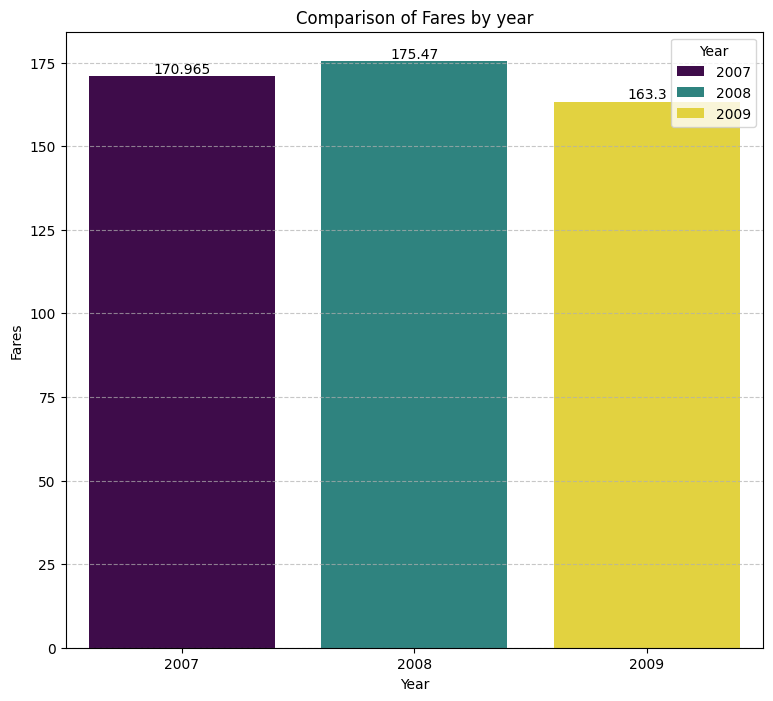

In [59]:
#Filtering the mean value of fares for the particular year
fares1_cur = da[(da['Year'] == 2007) & (da['city'] == 'New Orleans')]['cur_fare'].mean()
fares2_cur = da[(da['Year'] == 2008) & (da['city'] == 'New Orleans')]['cur_fare'].mean()
fares3_cur = da[(da['Year'] == 2009) & (da['city'] == 'New Orleans')]['cur_fare'].mean()

#storing the values as a dictionaries
tr1={'City':['New Orleans'],'Fares':[fares1_cur],'Year':[2007]}
tr2={'City':['New Orleans'],'Fares':[fares2_cur],'Year':[2008]}
tr3={'City':['New Orleans'],'Fares':[fares3_cur],'Year':[2009]}

#converting dictionaries to dataframe
pr1=pd.DataFrame(tr1)
pr2=pd.DataFrame(tr2)
pr3=pd.DataFrame(tr3)

#combining the dataframe with the help of concat() method
plt.figure(figsize=(9, 8))
tr=pd.concat([pr1,pr2,pr3])


sx=sns.barplot(x='Year',y='Fares',hue='Year',data=tr,palette='viridis')

#Adding title and label
plt.title('Comparison of Fares by year')
plt.xlabel('Year')
plt.ylabel('Fares')
plt.ylim(bottom=0) # Ensure y-axis starts at 0
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bars in sx.containers:
    sx.bar_label(bars)

plt.show()

In [67]:
da['log_passengers'] = np.log(da['cur_passengers'])
da['log_airfare'] = np.log(da['cur_fare'])

X = sm.add_constant(da['log_airfare'])
y = da['log_passengers']

model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         log_passengers   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     391.8
Date:                Thu, 01 Jan 2026   Prob (F-statistic):           3.57e-85
Time:                        14:54:50   Log-Likelihood:                -13371.
No. Observations:                8024   AIC:                         2.675e+04
Df Residuals:                    8022   BIC:                         2.676e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.9111      0.345     20.007      

In [41]:
seg_data = da.groupby('city').agg({
    'cur_fare': 'mean',
    'cur_passengers': 'sum'
}).reset_index()

seg_data.rename(columns={'cur_fare': 'avg_fare', 'cur_passengers': 'total_passengers'}, inplace=True)

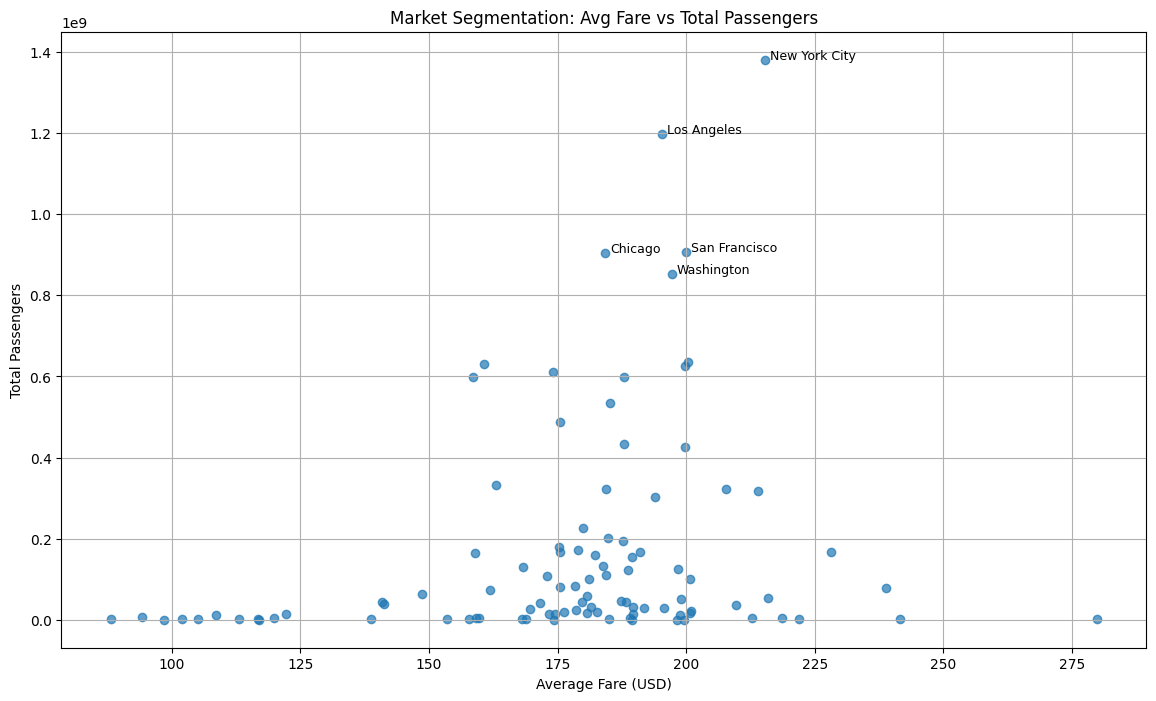

In [42]:
plt.figure(figsize=(14, 8))
plt.scatter(seg_data['avg_fare'], seg_data['total_passengers'], alpha=0.7)

# Label top cities (optional)
top_cities = seg_data.sort_values(by='total_passengers', ascending=False).head(5)
for _, row in top_cities.iterrows():
    plt.text(row['avg_fare'] + 1, row['total_passengers'], row['city'], fontsize=9)

plt.title('Market Segmentation: Avg Fare vs Total Passengers')
plt.xlabel('Average Fare (USD)')
plt.ylabel('Total Passengers')
plt.grid(True)
plt.show()

Conclusion:
    In conclusion, our data exploration revealed significant trends and patterns, providing valuable insights into our dataset. Key findings include a clear correlation between airfare and passenger numbers, highlighting that passenger counts are directly dependent on airfare rates. We also identified outliers that warrant further investigation and potential areas for deeper analysis. This preliminary exploration sets the stage for more detailed statistical analysis and predictive modeling, ensuring our subsequent steps are well-informed and targeted. Overall, this process has been crucial in understanding the dataset's structure and guiding future research directions.

In [43]:

da.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8024 entries, 0 to 8026
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Year            8024 non-null   int64  
 1   quarter         8024 non-null   int64  
 2   citymarketid    8024 non-null   int64  
 3   city            8024 non-null   object 
 4   City_code       8024 non-null   object 
 5   cur_passengers  8024 non-null   int64  
 6   cur_fare        8024 non-null   float64
 7   cur_yield       8024 non-null   float64
 8   distance        8024 non-null   int64  
 9   ly_passengers   8024 non-null   float64
 10  ly_fare         8024 non-null   float64
 11  ly_yield        8024 non-null   float64
 12  ly_distance     8024 non-null   float64
 13  trip_id         8024 non-null   int64  
dtypes: float64(6), int64(6), object(2)
memory usage: 940.3+ KB
